# MLP Combine with vector Space: 

Each word is mapped to a point in a continuous vector space via an embedding lookup.
Embeddings from the context are concatenated and passed through an MLP, which transforms these coordinates into logits.
Softmax normalizes the logits into a probability distribution over the vocabulary

In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt

c:\Users\Yashraj Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
words=open('names.txt','r').read().splitlines()
print(words[:8])

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
len(words)

32033

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [78]:
import random
# building the dataset
def build_dataset(words):
    block_size=3
    X,Y=[],[]
    for w in words:
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            context=context[1:]+[ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y


# Creating Training , Validation and Test sets
random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)
Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

In [79]:
print("Shape of X:",Xtr.shape) # Means there are 3 characters in the context in 32 training examples.
print("Data type of X:",Xtr.dtype)
print("Shape of Y:",Ytr.shape) # Means there is only 1 output character in 32 training examples.
print("Data type of Y:",Ytr.dtype)

Shape of X: torch.Size([182625, 3])
Data type of X: torch.int64
Shape of Y: torch.Size([182625])
Data type of Y: torch.int64


In [80]:
print(Xtr[:10])

tensor([[ 0,  0,  0],
        [ 0,  0, 25],
        [ 0, 25, 21],
        [25, 21,  8],
        [21,  8,  5],
        [ 8,  5, 14],
        [ 5, 14,  7],
        [ 0,  0,  0],
        [ 0,  0,  4],
        [ 0,  4,  9]])


### Input Embeddings:

In [8]:
### Generating the embeddings

C= torch.randn((27,2)) # 27 is the number of characters in the vocabulary and 2 is the size of the embedding vector for each character menas 2 dimensions for each character. We can choose any number of dimensions for the embedding vector, but 2 is a good choice for visualization purposes.
print(C[:10])

tensor([[ 0.6684, -0.3020],
        [-0.2022, -0.0876],
        [-1.0173,  0.5065],
        [ 1.4225, -0.4205],
        [ 1.1484,  0.2777],
        [-0.3921,  0.8927],
        [ 0.5763, -1.3110],
        [-1.7013,  0.0260],
        [ 1.5987, -1.3028],
        [ 0.1837,  0.3248]])


In [81]:
emb = C[Xtr] # (32,3,2) # 32 training examples, 3 characters in the context, and 2 dimensions for each character.(batch, context, embedding)
# means a context window of 3 characters is being mapped to a 2-dimensional embedding vector for each character in the context. So, we have a total of 32 training examples, and each example consists of a context window of 3 characters, which is represented as a 2-dimensional embedding vector for each character in the context.
# so in this, each particular charater in context is being mapped to a 2-dimensional embedding vector, and we have a total of 32 training examples, where each example consists of a context window of 3 characters, and each character in the context is represented as a 2-dimensional embedding vector.
print(emb[1][2][0]) # this is the first dimension of the embedding vector for the third character in the context of the second training example becuase of 0-based indexing.

tensor(-0.6102, grad_fn=<SelectBackward0>)


### Hidden layer

In [82]:
W1 = torch.randn((6,100)) # 6 is the number of input features (3 characters in the context * 2 dimensions for each character) and 100 is the number of neurons in the hidden layer.
b1 = torch.randn(100) # 100 is the number of neurons in the hidden layer.

# But There is a problem here, usually we to emb @ W1 + b1, but the shape of emb is (32,3,2) and the shape of W1 is (6,100), so we need to reshape emb to (32,6) before we can perform the matrix multiplication.
#emb_reshaped = torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],dim=1) # this is the first, second and third character in the context for all 32 training examples, reshaped to (32,6)
# emb_reshaped = torch.cat(torch.unbind(emb,dim=1)) # this will give us a list of 3 tensors, each of shape (32,2), which is the first, second and third character in the context for all 32 training examples.
emb_reshaped = emb.view(emb.shape[0], -1) # this will reshape the emb tensor to (32,6) by concatenating the 3 characters in the context for all 32 training examples.
# Now we can perform the matrix multiplication and add the bias to get the output of the hidden layer. shape will be (32,6) @ (6,100) + (100,) = (32,100)

In [83]:
h= torch.tanh(emb_reshaped @ W1 + b1) # this will give us the output of the hidden layer, which is a tensor of shape (32,100), where 32 is the number of training examples and 100 is the number of neurons in the hidden layer. Each row in this tensor represents the output of the hidden layer for a particular training example.
h

tensor([[ 0.8572,  0.9925,  0.0599,  ..., -0.9748, -0.6620,  0.9965],
        [ 0.2252,  0.9948,  0.3841,  ..., -0.6850, -0.4647,  0.8853],
        [ 0.9996,  0.9979,  0.9870,  ..., -0.8584, -0.4884,  0.5927],
        ...,
        [ 0.9580, -0.5028,  0.1525,  ..., -0.8647,  0.9981, -0.9952],
        [ 0.8068,  0.9620, -0.6758,  ..., -0.9234, -0.9870, -0.3342],
        [ 0.8748,  0.8243,  0.8701,  ..., -0.2432,  0.8821, -0.6064]],
       grad_fn=<TanhBackward0>)

### Output Layer:

In [84]:
w2= torch.randn((100,27)) # 100 is the number of neurons in the hidden layer and 27 is the number of characters in the vocabulary, which is also the number of output classes.
b2= torch.randn(27) # 27 is the number of characters in the vocabulary, which is also the number of output classes.

logits = h @ w2 + b2 # this will give us the logits for each of the 27 output classes for each of the 32 training examples. The shape of logits will be (32,27), where 32 is the number of training examples and 27 is the number of output classes.
count= logits.exp() # this will give us the unnormalized probabilities for each of the 27 output classes for each of the 32 training examples. The shape of count will be (32,27), where 32 is the number of training examples and 27 is the number of output classes.
prob= count / count.sum(dim=1, keepdim=True) # this will give us the normalized probabilities for each of the 27 output classes for each of the 32 training examples. The shape of prob will be (32,27), where 32 is the number of training examples and 27 is the number of output classes. Each row in this tensor represents a probability distribution over the 27 output classes for a particular training example.
prob[torch.arange(Xtr.shape[0]),Ytr] # this will give us the probabilities of the correct output class for each of the 32 training examples. The shape of this tensor will be (32,), where each element represents the probability of the correct output class for a particular training example. We can use these probabilities to compute the loss and perform backpropagation to update the weights and biases of the model during training.

tensor([2.1830e-04, 4.8951e-07, 2.6585e-12,  ..., 2.9546e-04, 5.2767e-09,
        1.1397e-03], grad_fn=<IndexBackward0>)

## Negative LogLikelihood:

In [85]:
loss=-prob[torch.arange(Xtr.shape[0]),Ytr].log().mean() # this will give us the average negative log-likelihood loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training.
loss

tensor(15.1729, grad_fn=<NegBackward0>)

The above way of computing the loss is not very efficient because we are computing the probabilities for all the output classes, which is not necessary. We can directly compute the loss from the logits without computing the probabilities, which is more efficient and numerically stable.

We can use the cross-entropy loss function, which combines the softmax function and the negative log-likelihood loss into a single function. The cross-entropy loss can be computed as follows:

loss = torch.nn.functional.cross_entropy(logits, Y) # scalar

why this is better?

reason 1: It is more efficient because we are not computing the probabilities for all the output classes, which is not necessary. We only need the logits for the correct output class to compute the loss, and the cross-entropy loss function allows us to do that directly without computing the probabilities.

reason 2: It is more numerically stable because it avoids the potential issues of computing the probabilities, which can lead to very small values that can cause underflow when taking the logarithm. The cross-entropy loss function is designed to handle this issue and provides a more stable way to compute the loss directly from the logits.

### ALL CODE IN CLEAR WAY:

### Weights and Bias:

In [106]:
G=torch.Generator().manual_seed(2147483647)
C= torch.randn((27,2), generator=G) 
W1 = torch.randn((6,100), generator=G)
b1 = torch.randn(100, generator=G)
W2 = torch.randn((100,27), generator=G)
b2 = torch.randn(27, generator=G)
parameters = [C, W1, b1, W2, b2]

In [107]:
#Number of parameters in the model
total_params = sum(p.numel() for p in parameters)
print(f'Total number of parameters in the model: {total_params}')

Total number of parameters in the model: 3481


### Finding out Learning Rate: 

In [87]:
lre = torch.linspace(-3, 0, 1000)   # exponent from 10^-3 to 10^0
lri = 10**lre                      # actual learning rate

### Gradient Calculation Turn on:

In [88]:
for p in parameters:
    p.requires_grad = True

In [95]:
Lr_exp = []
Lr = []
Loss = []
for i in range(30000):
    # Mini batch of 32 random examples from the training data
    # Mini-batch training speeds up optimization by trading exact gradients for frequent, efficient, and slightly noisy updates.
    ix=torch.randint(0,Xtr.shape[0],(32,)) # this will give us a tensor of shape (32,) containing random integers between 0 and 4, which we can use as indices to select a random batch of 32 training examples from the dataset. We can use these indices to index into the X and Y tensors to get the input and output for the selected batch of training examples.
    # Forward pass
    embeddings = C[Xtr[ix]] # (32,3,2)
    embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
    hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
    logits = hidden_layer_output @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytr[ix]) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training

    # Backward pass
    for p in parameters:
        p.grad = None # Gradients are accumulated by default in PyTorch, so we need to set them to None before calling backward() to prevent accumulation of gradients from previous iterations.
    loss.backward()

    # Update parameters using gradient descent
    lr=0.1
    with torch.no_grad():
        for p in parameters:
            p += -lr * p.grad

    # Track the learning rate and loss for visualization purposes
    # Lr.append(lr)
    # Lr.append(lri[i])
    # Lr_exp.append(lre[i])
    # Loss.append(loss.item())



In [96]:
print(loss.item())

2.215841293334961


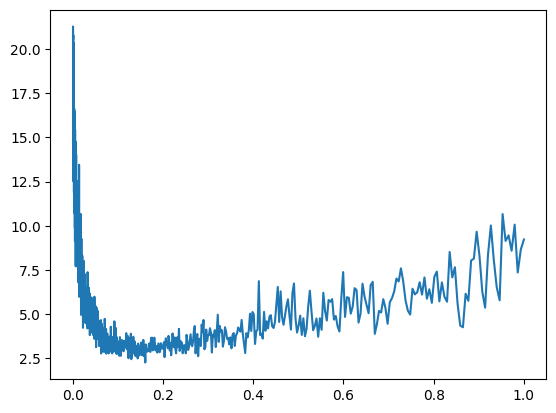

In [62]:
plt.plot(Lr, Loss)

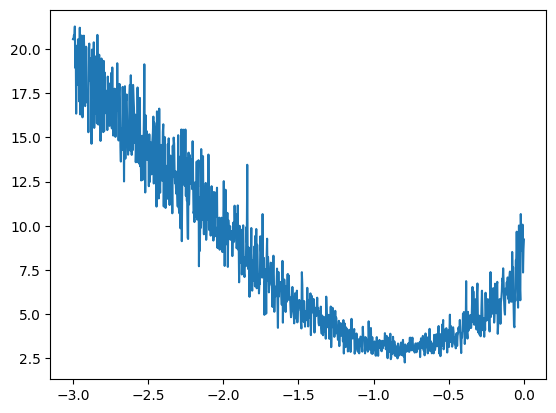

In [61]:
plt.plot(Lr_exp, Loss)

In [102]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xtr] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ytr) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.375892400741577


In [101]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xdev] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ydev) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.379326105117798


# If our training and validation loss turns out to be close it means our network parameters are too small and we need bigger NN with larger parameters

### Bigger Network:

In [139]:
G=torch.Generator().manual_seed(2147483647)
C= torch.randn((27,2), generator=G) 
W1 = torch.randn((6,300), generator=G)
b1 = torch.randn(300, generator=G)
W2 = torch.randn((300,27), generator=G)
b2 = torch.randn(27, generator=G)
parameters = [C, W1, b1, W2, b2]

In [140]:
#Number of parameters in the model
total_params = sum(p.numel() for p in parameters)
print(f'Total number of parameters in the model: {total_params}')

Total number of parameters in the model: 10281


In [141]:
for p in parameters:
    p.requires_grad = True

In [148]:
for i in range(30000):
    # Mini batch of 32 random examples from the training data
    # Mini-batch training speeds up optimization by trading exact gradients for frequent, efficient, and slightly noisy updates.
    ix=torch.randint(0,Xtr.shape[0],(32,)) # this will give us a tensor of shape (32,) containing random integers between 0 and 4, which we can use as indices to select a random batch of 32 training examples from the dataset. We can use these indices to index into the X and Y tensors to get the input and output for the selected batch of training examples.
    # Forward pass
    embeddings = C[Xtr[ix]] # (32,3,2)
    embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
    hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
    logits = hidden_layer_output @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytr[ix]) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training

    # Backward pass
    for p in parameters:
        p.grad = None # Gradients are accumulated by default in PyTorch, so we need to set them to None before calling backward() to prevent accumulation of gradients from previous iterations.
    loss.backward()

    # Update parameters using gradient descent
    lr=0.05
    with torch.no_grad():
        for p in parameters:
            p += -lr * p.grad


print(loss.item())

2.3305914402008057


In [150]:
# After training the model for 30000 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xtr] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,300)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ytr) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.3648979663848877


In [149]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xdev] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ydev) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.36633038520813


### Making A Bigger Dimension LookUp table:

In [169]:
G=torch.Generator().manual_seed(2147483647)
C= torch.randn((27,10), generator=G) 
W1 = torch.randn((30,200), generator=G)
b1 = torch.randn(200, generator=G)
W2 = torch.randn((200,27), generator=G)
b2 = torch.randn(27, generator=G)
parameters = [C, W1, b1, W2, b2]

In [170]:
# Number of parameters in the model
total_params = sum(p.numel() for p in parameters)
print(f'Total number of parameters in the model: {total_params}')

Total number of parameters in the model: 11897


In [171]:
for p in parameters:
    p.requires_grad = True

In [172]:
for i in range(500000):
    # Mini batch of 32 random examples from the training data
    # Mini-batch training speeds up optimization by trading exact gradients for frequent, efficient, and slightly noisy updates.
    ix=torch.randint(0,Xtr.shape[0],(32,)) # this will give us a tensor of shape (32,) containing random integers between 0 and 4, which we can use as indices to select a random batch of 32 training examples from the dataset. We can use these indices to index into the X and Y tensors to get the input and output for the selected batch of training examples.
    # Forward pass
    embeddings = C[Xtr[ix]] # (32,3,2)
    embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
    hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
    logits = hidden_layer_output @ W2 + b2 # (32,27)
    loss=F.cross_entropy(logits, Ytr[ix]) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training

    # Backward pass
    for p in parameters:
        p.grad = None # Gradients are accumulated by default in PyTorch, so we need to set them to None before calling backward() to prevent accumulation of gradients from previous iterations.
    loss.backward()

    # Update parameters using gradient descent
    lr=0.1 if i < 100000 else 0.01
    with torch.no_grad():
        for p in parameters:
            p += -lr * p.grad
 
print(loss.item())

1.8242958784103394


In [174]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xtr] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ytr) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.105283737182617


In [173]:
# After training the model for 100 iterations, we can evaluate the final loss on the entire training dataset to see how well the model has learned to predict the next character based on the context of the previous characters.
random.seed(42)
embeddings = C[Xdev] # (32,3,2)
embeddings_reshaped = embeddings.view(embeddings.shape[0], -1) # (32,6)
hidden_layer_output = torch.tanh(embeddings_reshaped @ W1 + b1) # (32,100)
logits = hidden_layer_output @ W2 + b2 # (32,27)
loss=F.cross_entropy(logits, Ydev) # this will give us the average cross-entropy loss for the 32 training examples. The shape of this tensor will be a scalar, which represents the average loss for the batch of training examples. We can use this loss to perform backpropagation and update the weights and biases of the model during training
print(loss.item())

2.158959150314331


# Sampling from the model:

In [178]:
g = torch.Generator().manual_seed(2147483647)

block_size = 3

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:

        # 1. Get embeddings for current context
        emb = C[torch.tensor(context)]   # (3, d)

        # 2. Flatten
        x = emb.view(1, -1)              # (1, 3*d)

        # 3. Forward pass
        h = torch.tanh(x @ W1 + b1)      # (1, 100)
        logits = h @ W2 + b2             # (1, 27)
        probs = F.softmax(logits, dim=1) # (1, 27)

        # 4. Sample
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # 5. Update context
        context = context[1:] + [ix]

        # 6. Append
        out.append(itos[ix])

        if ix == 0:
            break

    print(''.join(out))


dex.
mariah.
makilah.
tyharlonie.
train.
lucan.
katha.
samiyah.
javer.
gotti.
molie.
kavo.
kented.
gen.
emma.
sadel.
tkaverni.
folsper.
camendtarlyn.
kashra.
